# Forecast VAR: World Cup 2026 Prediction Agent

This notebook is the end-to-end story for Episode 2. It uses deterministic mock mode so it can run without API cost.

## 1. Validate the tournament field

The first rule of a prediction agent: know who actually qualified. Italy is intentionally checked as absent.

In [1]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()/"src"))
from forecast_var.tools import validate_tournament_field, get_source_registry, forecast_group, rank_teams
from forecast_var.runner import run_agent
from forecast_var.backtest import run_backtest
validation = validate_tournament_field()
validation

{'valid': True,
 'group_count': 12,
 'team_count': 48,
 'unique_team_count': 48,
 'italy_in_field': False,
 'groups_with_wrong_size': {},
 'citations': [{'id': 'CITE-SRC-FIFA-WC26',
   'source_id': 'SRC-FIFA-WC26',
   'title': 'FIFA World Cup 2026 official tournament page',
   'url': 'https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026',
   'detail': 'Official tournament page should be the primary refresh source.'},
  {'id': 'CITE-SRC-WIKI-WC26',
   'source_id': 'SRC-WIKI-WC26',
   'title': '2026 FIFA World Cup',
   'url': 'https://en.wikipedia.org/wiki/2026_FIFA_World_Cup',
   'detail': 'Cross-check source for group field and tournament format.'}]}

## 2. Source registry

The agent is designed to support many source types, but the repo bundles only legal/reproducible demo inputs.

In [2]:
registry = get_source_registry()
[(s["id"], s["status"], s["category"]) for s in registry["sources"]]

[('SRC-FIFA-WC26', 'bundled_and_refreshable', 'official_fixture_field'),
 ('SRC-WIKI-WC26', 'bundled_crosscheck', 'crosscheck'),
 ('SRC-FIFA-RANKINGS', 'adapter_placeholder', 'team_strength'),
 ('SRC-WORLD-ELO', 'adapter_placeholder', 'team_strength'),
 ('SRC-CLUB-ELO', 'adapter_placeholder', 'player_pool_proxy'),
 ('SRC-FOOTBALL-DATA', 'adapter_placeholder', 'historical_results_odds'),
 ('SRC-INJURY-NEWS', 'manual_or_paid_adapter', 'squad_availability'),
 ('SRC-BETTING-MARKET', 'disabled_optional', 'external_consensus'),
 ('SRC-SAMPLE-TEAM-PRIORS', 'bundled_demo_only', 'demo_features'),
 ('MODEL-FORECAST-VAR-V1', 'bundled_demo_model', 'model')]

## 3. Group D forecast

This is a viewer-friendly example because it includes the co-host USA and Australia.

In [3]:
group_d = forecast_group("D", sims=3000)
group_d["group_probabilities"]

{'USA': {'winner': 0.4797, 'top2': 0.736, 'top3': 0.896},
 'Paraguay': {'winner': 0.1647, 'top2': 0.4043, 'top3': 0.713},
 'Australia': {'winner': 0.136, 'top2': 0.3283, 'top3': 0.6187},
 'Türkiye': {'winner': 0.2197, 'top2': 0.5313, 'top3': 0.7723}}

Wrote figures to /mnt/data/wc26-forecast-var-agent-episode2/figures


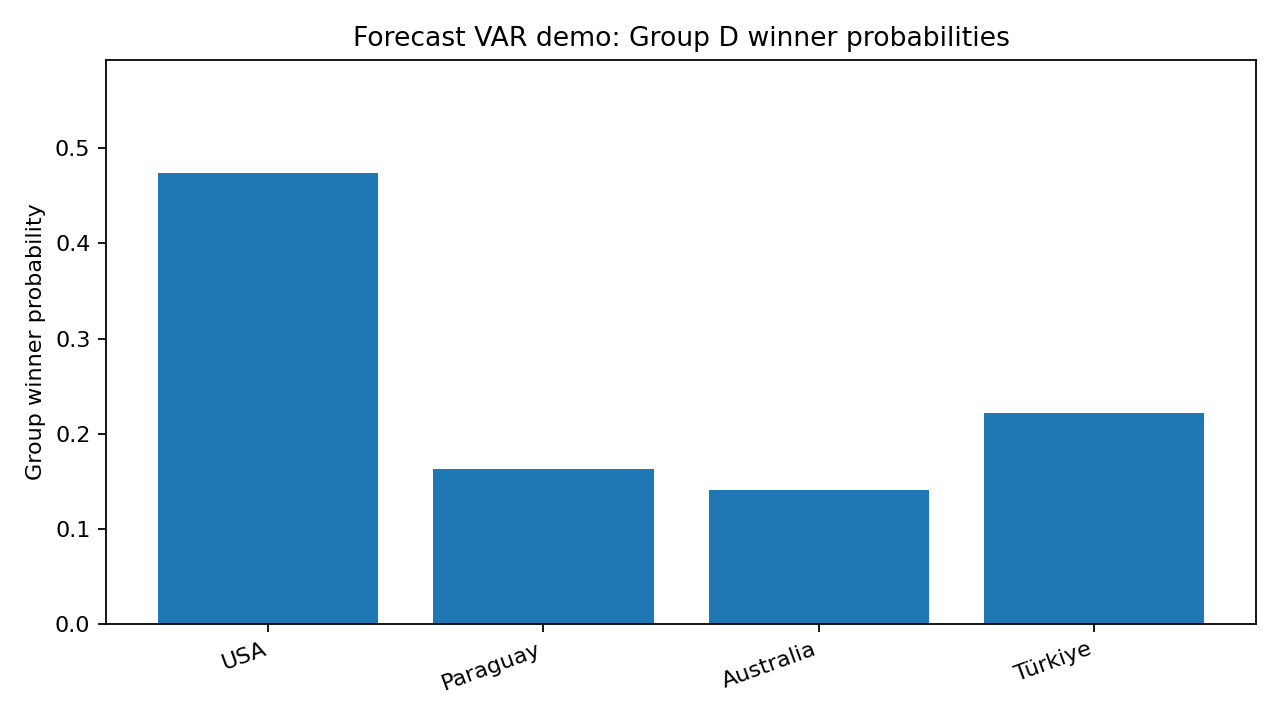

In [4]:
from IPython.display import Image, display
import subprocess, os
env = {**os.environ, "PYTHONPATH": "src"}
subprocess.run(["python", "scripts/generate_figures.py"], check=True, env=env)
display(Image(filename="figures/group_d_winner_probabilities.png"))

## 4. Top tournament favourites

This is a demo title-probability proxy, not a full bracket simulation.

In [5]:
top = rank_teams(10)
top["ranked"][:10]

[{'team': 'Argentina', 'demo_title_probability': 0.087, 'rating_used': 2063.7},
 {'team': 'France', 'demo_title_probability': 0.0801, 'rating_used': 2053.7},
 {'team': 'Spain', 'demo_title_probability': 0.0737, 'rating_used': 2043.7},
 {'team': 'England', 'demo_title_probability': 0.0678, 'rating_used': 2033.7},
 {'team': 'Portugal', 'demo_title_probability': 0.0598, 'rating_used': 2018.7},
 {'team': 'Brazil', 'demo_title_probability': 0.0565, 'rating_used': 2011.9},
 {'team': 'Netherlands',
  'demo_title_probability': 0.0428,
  'rating_used': 1978.7},
 {'team': 'Germany', 'demo_title_probability': 0.0411, 'rating_used': 1973.7},
 {'team': 'Belgium', 'demo_title_probability': 0.0378, 'rating_used': 1963.7},
 {'team': 'Croatia', 'demo_title_probability': 0.0282, 'rating_used': 1928.7}]

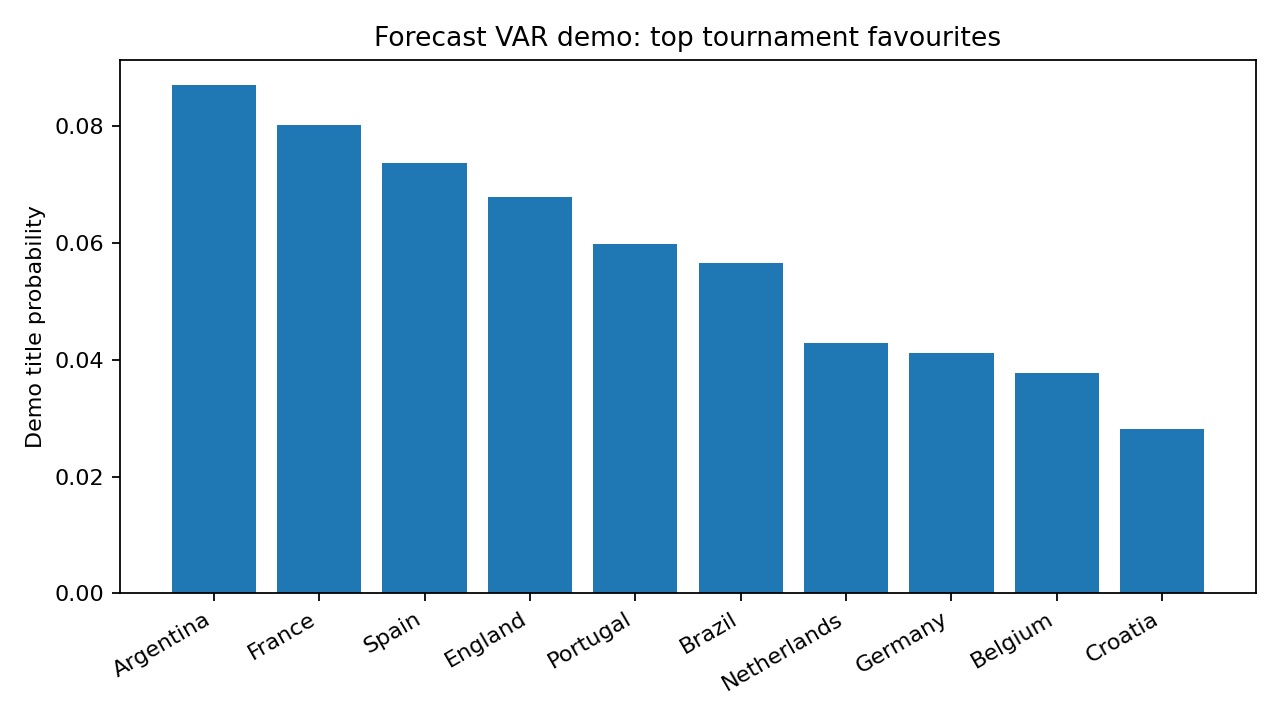

In [6]:
display(Image(filename="figures/top_tournament_favourites.png"))

## 5. Scenario analysis

A useful prediction agent should handle scenarios without pretending they are confirmed news.

In [7]:
scenario_answer = run_agent("If France loses 80 rating points because of injuries, how does that change the top favourites?", mode="grounded_mock")
scenario_answer.model_dump()

{'answer': 'Scenario run: France loses 80 rating points because of user-specified injuries. Under that scenario, France drops out of the top 5. The top 5 probabilities are Argentina 9.0%, Spain 7.7%, England 7.0%, Portugal 6.2%, Brazil 5.9%. This probability scenario is not confirmed injury news and does not imply injuries decide the tournament.',
 'claims': [{'text': 'Scenario run: France loses 80 rating points because of user-specified injuries. Under that scenario, France drops out of the top 5. The top 5 probabilities are Argentina 9.0%, Spain 7.7%, England 7.0%, Portugal 6.2%, Brazil 5.9%. This probability scenario is not confirmed injury news and does not imply injuries decide the tournament.',
   'citation_ids': ['CITE-SRC-SAMPLE-TEAM-PRIORS',
    'CITE-MODEL-FORECAST-VAR-V1',
    'CITE-SRC-FIFA-WC26']}],
 'citations': [{'id': 'CITE-SRC-SAMPLE-TEAM-PRIORS',
   'source_id': 'SRC-SAMPLE-TEAM-PRIORS',
   'title': 'SRC-SAMPLE-TEAM-PRIORS',
   'url': '',
   'detail': ''},
  {'id': 'C

## 6. Baseline vs grounded agent evaluation

The baseline makes unsupported claims. The grounded agent must use tools, skills, citations, probabilities, and abstention.

In [8]:
import subprocess, json, os
env = {**os.environ, "PYTHONPATH": "src"}
subprocess.run(["python", "scripts/evaluate.py", "--mode", "baseline_mock"], check=True, env=env)
subprocess.run(["python", "scripts/evaluate.py", "--mode", "grounded_mock"], check=True, env=env)
subprocess.run(["python", "scripts/generate_figures.py"], check=True, env=env)
base = json.load(open("reports/summary_baseline_mock.json"))
grounded = json.load(open("reports/summary_grounded_mock.json"))
base, grounded

{
  "cases": 7,
  "pass_rate": 0.0,
  "tool_recall": 0.0,
  "skill_recall": 0.0,
  "citation_recall": 0.0,
  "unsupported_claim_rate": 1.0,
  "abstention_accuracy": 0.8571428571428571,
  "probability_sanity_rate": 0.2857142857142857
}


{
  "cases": 7,
  "pass_rate": 1.0,
  "tool_recall": 1.0,
  "skill_recall": 1.0,
  "citation_recall": 1.0,
  "unsupported_claim_rate": 0.0,
  "abstention_accuracy": 1.0,
  "probability_sanity_rate": 1.0
}


Wrote figures to /mnt/data/wc26-forecast-var-agent-episode2/figures


({'cases': 7,
  'pass_rate': 0.0,
  'tool_recall': 0.0,
  'skill_recall': 0.0,
  'citation_recall': 0.0,
  'unsupported_claim_rate': 1.0,
  'abstention_accuracy': 0.8571428571428571,
  'probability_sanity_rate': 0.2857142857142857},
 {'cases': 7,
  'pass_rate': 1.0,
  'tool_recall': 1.0,
  'skill_recall': 1.0,
  'citation_recall': 1.0,
  'unsupported_claim_rate': 0.0,
  'abstention_accuracy': 1.0,
  'probability_sanity_rate': 1.0})

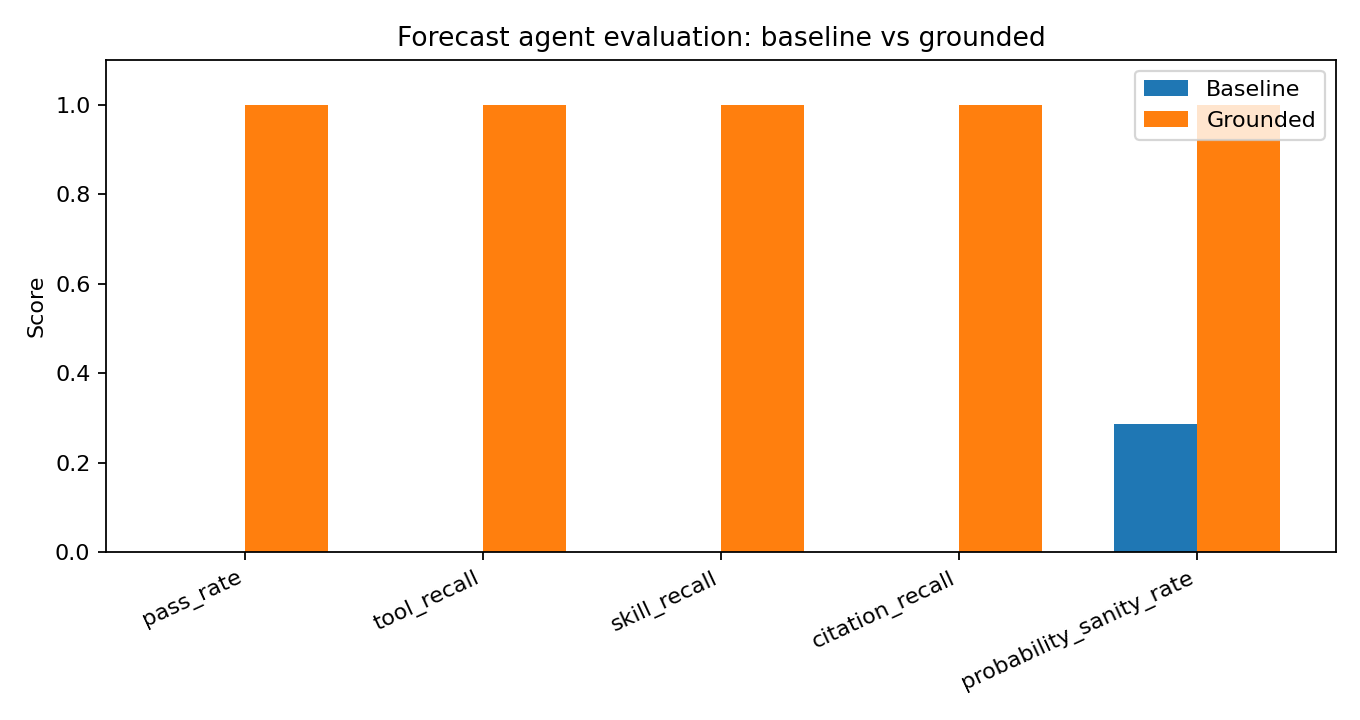

In [9]:
display(Image(filename="figures/eval_summary.png"))

## 7. Forecast model backtest harness

A prediction agent needs both answer evaluation and model evaluation. This toy backtest computes log loss and Brier score on a small historical sample.

In [10]:
backtest = run_backtest()
{k:v for k,v in backtest.items() if k != "rows"}

{'matches': 12,
 'mean_log_loss': 1.1574,
 'mean_brier': 0.6935,
 'note': 'Illustrative backtest harness. Replace sample ratings with timestamped historical ratings for a serious model audit.'}

## 8. Live OpenAI API path

The notebook uses mock mode for reproducibility. To run the real OpenAI agent with MCP tools:

```bash
export OPENAI_API_KEY="your_key_here"
PYTHONPATH=src python scripts/run_agent.py "Who is favourite to win Group D?" --mode openai --model gpt-4.1-mini
```

The live implementation is in `src/forecast_var/openai_agent.py`.